# Statistisk processtyrning av beläggningstjocklek över produktionslinjer med PROC BOXPLOT

## Sammanfattning

Denna notebook använder **PROC BOXPLOT** för att utföra statistisk processtyrning (SPC) på en kvalitetskritisk mätning av beläggningstjocklek insamlad över fyra parallella produktionslinjer. Vi genererar syntetiska mätdata inline, profilerar linjerna med `PROC MEANS` och ritar skelettartade och schematiska lådagram (box-and-whisker) som jämför läge, spridning och svansar mellan linjerna i ett enda diagram.

Vi bedömer sedan varje linje mot den tekniska specifikationen (målvärde 50,00 mm, gränser 49,80–50,20 mm) direkt från statistikdatasetet **`OUTBOX=`** — de exakta kvartilerna, staketen (fences) och morrhårsändpunkterna bakom varje låda — och demonstrerar slutligen tur-och-retur-flödet **`OUTHISTORY=` / `HISTORY=`**: PROC BOXPLOT exporterar en kompakt sammanfattningsrad per linje, och en andra PROC BOXPLOT rekonstruerar ett identiskt diagram direkt från den sammanfattningen, det mönster en daglig SPC-instrumentpanel använder för att rita om utan att skanna om rådata.

Över de fyra linjerna är **LINE-A bäst centrerad** på målvärdet (medelvärde 50,008 mm), **LINE-C ligger lågt** (medelvärde 49,932 mm, driver mot LSL), och **LINE-D ligger både högt och är mest variabel** (medelvärde 50,102 mm, standardavvikelse 0,080 mm) — dess maximum på 50,248 mm är den enda observationen som överskrider den övre specifikationsgränsen på 50,20 mm.

## Datakällor

All data är syntetisk och genereras inline av det första DATA-steget med `call streaminit(20250531)` och `rand()`. Ingen extern indata eller nätverksindata används. Det fasta fröet gör varje tal i denna notebook reproducerbart.

**Dataset: `ProcessMeas`** (en rad per uppmätt detalj)

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `Line` | Char(6) | Produktionslinjens identifierare: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (grupp-/klassificeringsvariabeln) |
| `Shift` | Num | Produktionsskiftsindex 1–6 (inför mild drift mellan skift) |
| `Thickness` | Num | Beläggningstjocklek i mm (analysvariabeln); målvärde 50,00 mm, specifikationsgränser 49,80–50,20 mm |

Varje linje är centrerad kring ett något olika medelvärde (50,00 / 50,04 / 49,92 / 50,10) med linjespecifik variation, vilket efterliknar verkliga skillnader mellan utrustningar, och `LINE-B` injicerar ibland en liten positiv avvikelse. DATA-steget itererar över sex skift och fyra linjer med delgruppsstorlekar på ungefär 18–25 detaljer vardera; i denna olicensierade miljö begränsar motorn utdata till de första **100 observationerna**, vilket här landar som **38 / 19 / 21 / 22** detaljer för LINE-A till LINE-D — fortfarande rikligt för att fylla fyra väldefinierade lådor.

# Statistisk processtyrning av beläggningstjocklek med PROC BOXPLOT

I storskalig tillverkning är lådagrammet SPC:ns arbetshäst på verkstadsgolvet: det sammanfattar centraltendens, spridning och avvikande värden hos en kvalitetsegenskap för varje produktionsenhet i ett enda diagram. Här övervakar vi **beläggningstjocklek (mm)** på en detalj som produceras parallellt på fyra linjer (`LINE-A` till `LINE-D`). Den tekniska specifikationen är ett målvärde på **50,00 mm** med en nedre specifikationsgräns (LSL) på **49,80 mm** och en övre specifikationsgräns (USL) på **50,20 mm**.

Vi kommer att:

1. Generera ett syntetiskt mätdataset inline.
2. Profilera linjerna med `PROC MEANS`.
3. Rita ett grundläggande skelettartat lådagram, sedan ett schematiskt diagram, och lägga över specifikationsgränserna som referenslinjer.
4. Fånga varje beräknad lådstatistik med `OUTBOX=` och bedöma varje linje mot specifikationsgränserna från den tabellen.
5. Bevara en kompakt delgruppssammanfattning med `OUTHISTORY=` och bevisa tur-och-retur genom att rita om direkt från den med `HISTORY=`.

## Steg 1 — Generera syntetiska processmätningar

DATA-steget nedan simulerar mätningar över sex skift på fyra linjer. Varje linje är avsiktligt centrerad kring ett något olika medelvärde med sin egen variation, vilket efterliknar verkliga skillnader mellan utrustningar, och en mild drift mellan skift läggs på med en `sin(Shift)`-term. Ett fast frö (`streaminit(20250531)`) gör varje värde i denna notebook reproducerbart.

In [1]:
data ProcessMeas;
   CALL streaminit(20250531);
   LÄNGD Line $6;
   FÄLT lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   FÄLT lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   FÄLT LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   ETIKETT Thickness='Beläggningstjocklek (mm)' Line='Produktionslinje';
   GÖR Shift = 1 TILL 6;
      GÖR li = 1 TILL 4;
         Line = lines[li];
         /* varying subgroup size per line/shift */
         n = 18 + floor(rand('uniform') * 8);
         GÖR u = 1 TILL n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINE-B injects occasional high excursions */
            OM li = 2 AND rand('uniform') < 0.05 SÅ
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            UTDATA;
         SLUT;
      SLUT;
   SLUT;
   TA_BORT li u n BASE;
KÖR;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Steg 2 — Profilera linjerna

Före ritning bekräftar en snabb `PROC MEANS` att data landade som avsett: fyra linjer, blygsamma men icke-triviala stickprovsstorlekar, och medelvärden samlade nära målvärdet 50,00 mm med linjespecifik spridning. Detta är den numeriska ryggraden som lådagrammet kommer att visualisera.

In [2]:
PROCEDUR MEDELVÄRDEN data=ProcessMeas n mean std MIN MAX maxdec=3;
   KLASS Line;
   VARIABEL Thickness;
   ETIKETT Line='Produktionslinje' Thickness='Beläggningstjocklek (mm)';
   TITEL 'Sammanfattning av beläggningstjocklek per produktionslinje';
KÖR;

                               Sammanfattning av beläggningstjocklek per produktionslinje                               

                                                  The MEANS Procedure

                                Analysis Variable : Thickness Beläggningstjocklek (mm)

        Produktionslinje          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------------
        LINE-A                       38         50.008          0.045         49.914         50.097
        LINE-B                       19         50.052          0.051         49.921         50.114
        LINE-C                       21         49.932          0.050         49.835         50.002
        LINE-D                       22         50.102          0.080         49.963         50.248
        -------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Steg 3 — Grundläggande skelettartat lådagram

Det enklaste anropet behöver bara satsen `PLOT analysvariabel * gruppvariabel`. Standardvärdet `BOXSTYLE=SKELETAL` ritar morrhår till de mest extrema observationerna inom varje linje, vilket ger en snabb visuell jämförelse av läge och spridning över `LINE-A` till `LINE-D`.

                                Skelettartat lådagram över beläggningstjocklek per linje                                

                              Skelettartat lådagram över beläggningstjocklek per linje

                                                 The BOXPLOT Procedure

Skeletal Plots for Beläggningstjocklek (mm)

Produktionslinje      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10   


NOTE: Option TITLE changed to Skelettartat lådagram över beläggningstjocklek per linje.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


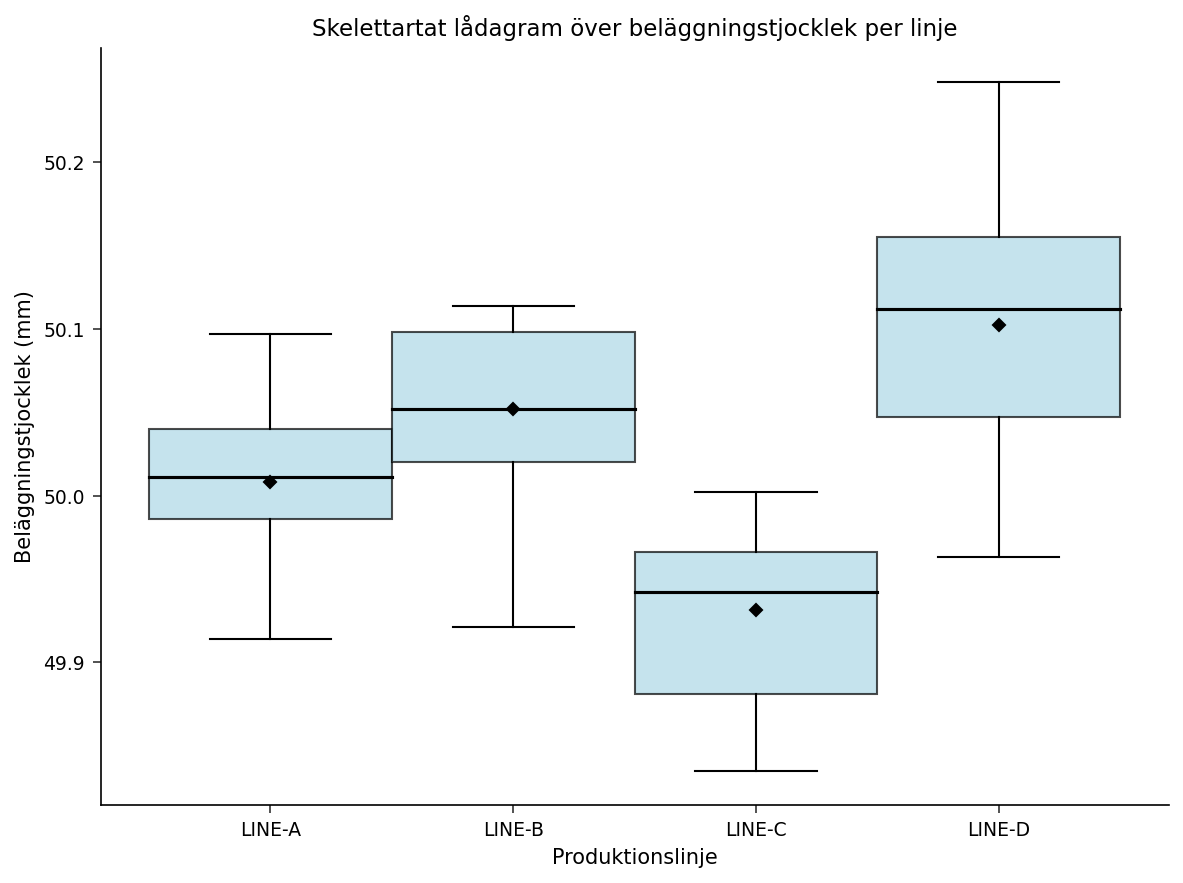

In [3]:
TITEL 'Skelettartat lådagram över beläggningstjocklek per linje';
PROCEDUR boxplot data=ProcessMeas;
   PLOT Thickness*Line;
KÖR;

## Steg 4 — Schematiskt lådagram

Vi byter till `BOXSTYLE=SCHEMATIC`. I schematisk stil kapas varje morrhår vid den mest extrema observationen som fortfarande ligger innanför staketen 1,5 × IQR, och varje punkt bortom ett staket ritas som en enskild markör för avvikande värde. I detta stickprov har ingen linje ett avvikande värde utanför staketet — varje linjes spridning är tillräckligt kompakt för att morrhåren når det verkliga minimum och maximum — så det schematiska diagrammet ser ut som det skelettartade, vilket i sig är ett användbart resultat: det talar om för ingenjören att ingen av de fyra linjerna kastar ut extrema detaljer. Lådkropparna gör fortfarande linje-till-linje-förskjutningarna uppenbara vid en snabb blick, och Steg 5 kvantifierar dem mot specifikationsgränserna.

                              SPC schematiskt lådagram över beläggningstjocklek per linje                               

                             SPC schematiskt lådagram över beläggningstjocklek per linje

                                                 The BOXPLOT Procedure

Schematic Plots for Beläggningstjocklek (mm)

Produktionslinje      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10


NOTE: Option TITLE changed to SPC schematiskt lådagram över beläggningstjocklek per linje.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


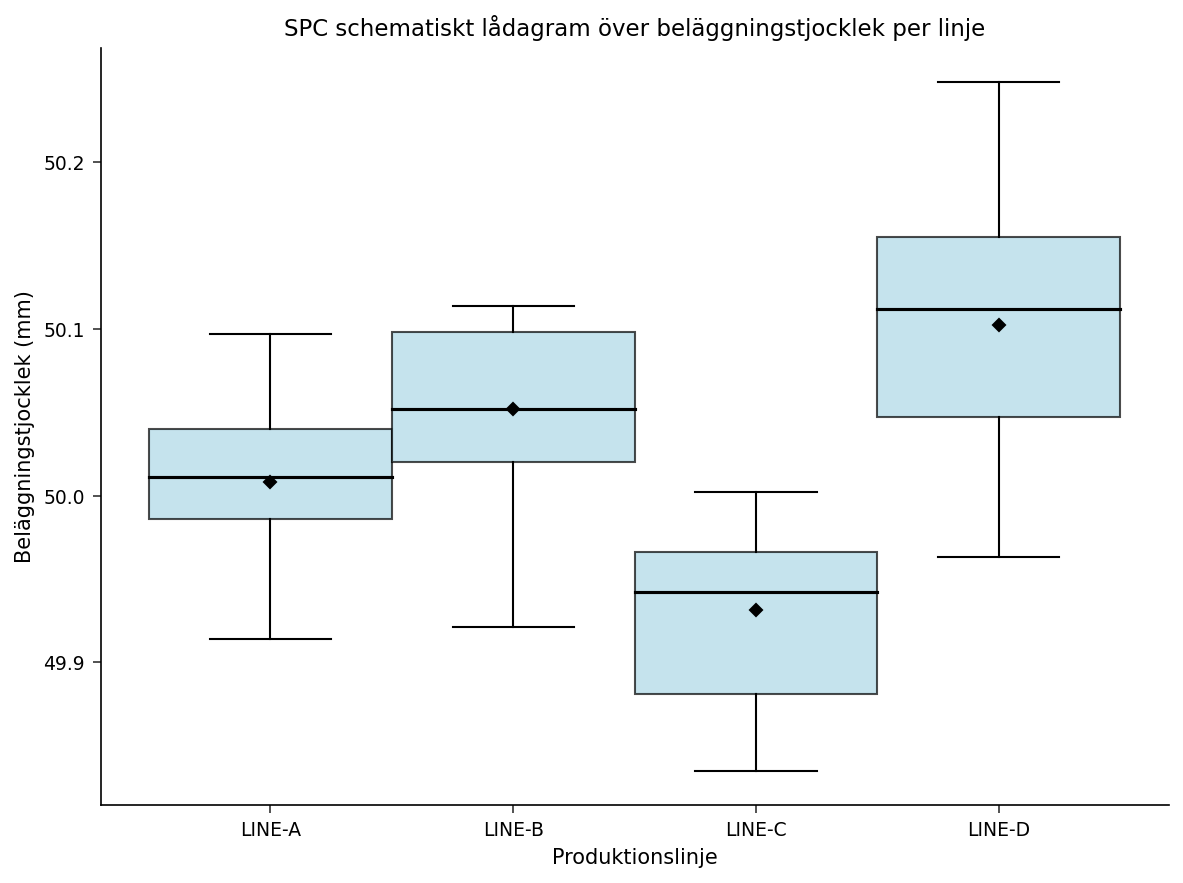

In [4]:
TITEL 'SPC schematiskt lådagram över beläggningstjocklek per linje';
PROCEDUR boxplot data=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
KÖR;

## Steg 5 — Exportera lådstatistik och bedöm mot specifikationsgränserna

Alternativet `OUTBOX=` fångar varje beräknad lådstatistik till ett dataset — för varje linje: det låga morrhåret (`L`), Q1 (`1`), medelvärde (`X`), median (`M`), Q3 (`3`), det höga morrhåret (`H`), standardavvikelse (`S`) och N. Detta är den numeriska dokumentation en revisor behöver bakom bilden, och det är också det renaste sättet att kontrollera varje linje mot specifikationen 49,80 / 50,20 mm. Vi aktiverar `GRID` för enklare läsning, exporterar `BoxStats`, skriver ut det, och kör sedan ett kort DATA-steg som flaggar varje linje vars morrhårsintervall skjuter förbi en specifikationsgräns.

                                  Schematiskt lådagram med rutnät och statistikexport                                   

                                 Schematiskt lådagram med rutnät och statistikexport

                                                 The BOXPLOT Procedure

Schematic Plots for Beläggningstjocklek (mm)

Produktionslinje      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10    


NOTE: Option TITLE changed to Schematiskt lådagram med rutnät och statistikexport.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Beräknad lådstatistik (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Bedömning mot specifikationsgränser per linje.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


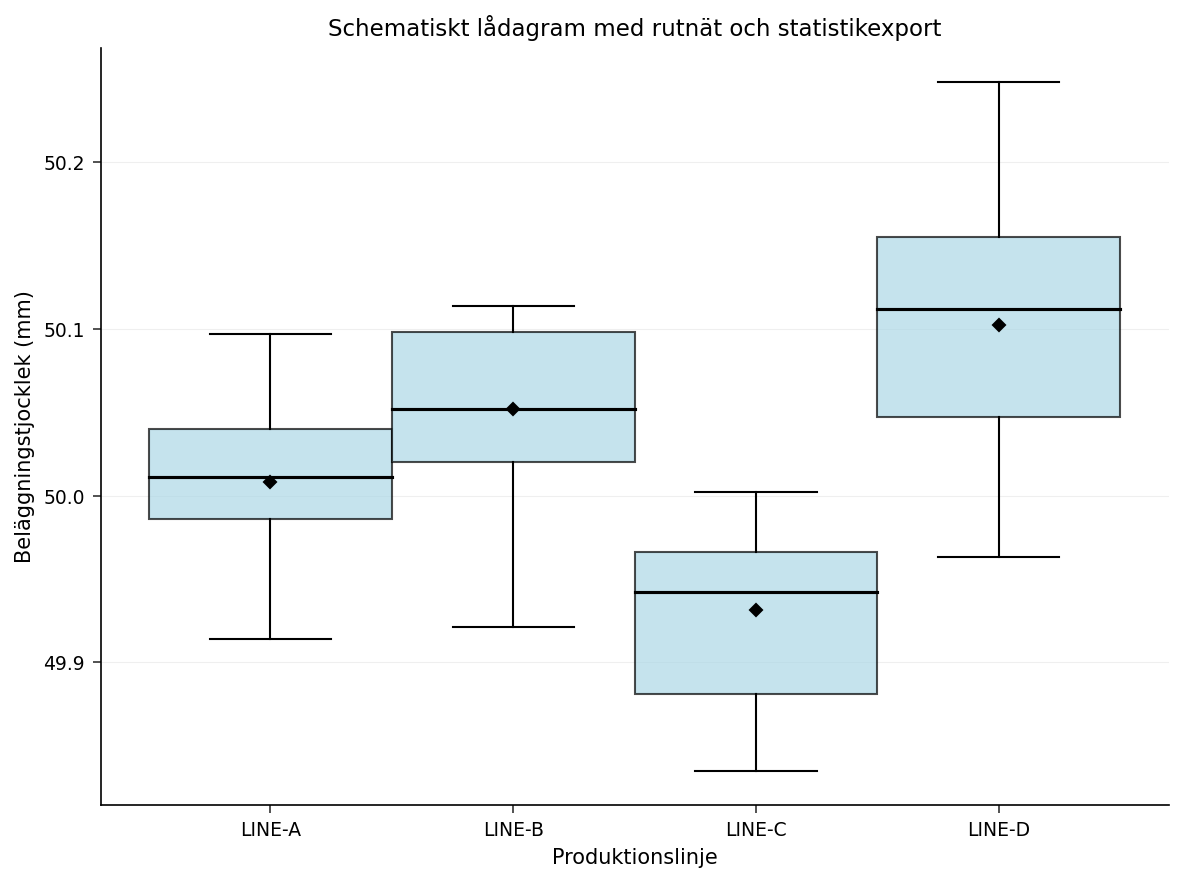

In [5]:
TITEL 'Schematiskt lådagram med rutnät och statistikexport';
PROCEDUR boxplot data=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
KÖR;

TITEL 'Beräknad lådstatistik (OUTBOX=)';
PROCEDUR SKRIV data=BoxStats noobs;
KÖR;

/* Assess each line against the 49.80 / 50.20 mm specification    */
/* using the exported whisker endpoints (THICKNESSL = low whisker, */
/* THICKNESSH = high whisker).                                     */
data SpecCheck;
   STÄLL_IN BoxStats;
   LÄNGD Status $48;
   LSL = 49.80;
   USL = 50.20;
   OM THICKNESSH > USL SÅ Status = 'Höga detaljer överstiger USL';
   ANNARS OM THICKNESSL < LSL SÅ Status = 'Låga detaljer under LSL';
   ANNARS Status = 'Inom specifikation';
   BEHÅLL LINE THICKNESSL THICKNESSH LSL USL Status;
KÖR;

TITEL 'Bedömning mot specifikationsgränser per linje';
PROCEDUR SKRIV data=SpecCheck noobs;
KÖR;

## Steg 6 — Bevara en övervakningshistorik och rita om från den

I löpande SPC skannar man sällan om varje rå mätning. `OUTHISTORY=` skriver en sammanfattningsrad per linje (samma layout som `HISTORY=` konsumerar), så de tunga rådata kan arkiveras. Nedan exporterar vi `LineHistory`, skriver ut det, och bevisar sedan tur-och-retur genom att mata tillbaka det direkt in i en ny `PROC BOXPLOT` via `HISTORY=` — exakt hur en daglig instrumentpanel skulle återanvända föraggregerad delgruppsstatistik.

                                              Exportera delgruppshistorik                                               

                                              Exportera delgruppshistorik

                                                 The BOXPLOT Procedure

Skeletal Plots for Beläggningstjocklek (mm)

Produktionslinje      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
--


NOTE: Option TITLE changed to Exportera delgruppshistorik.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Sammanfattande historikdataset (en rad per linje).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Lådagram återskapat från sammanfattande historik.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


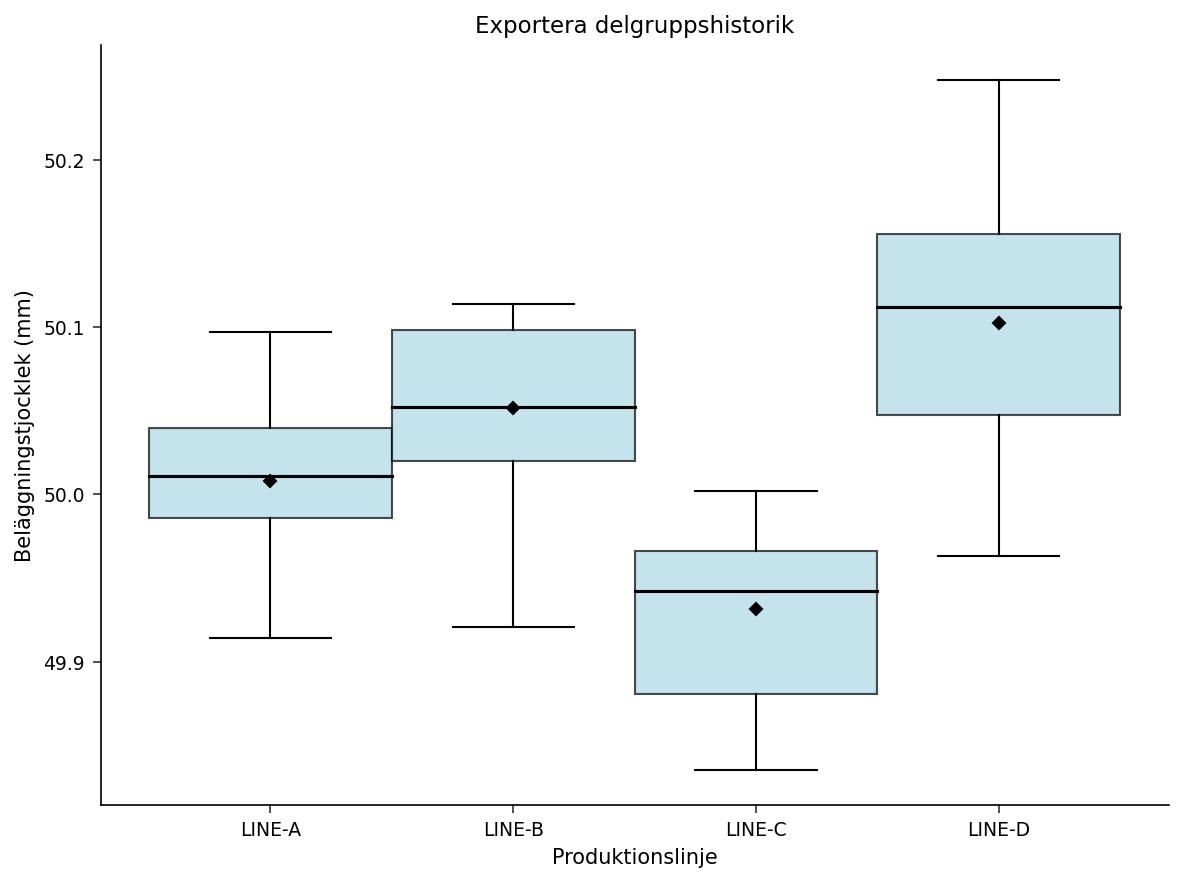

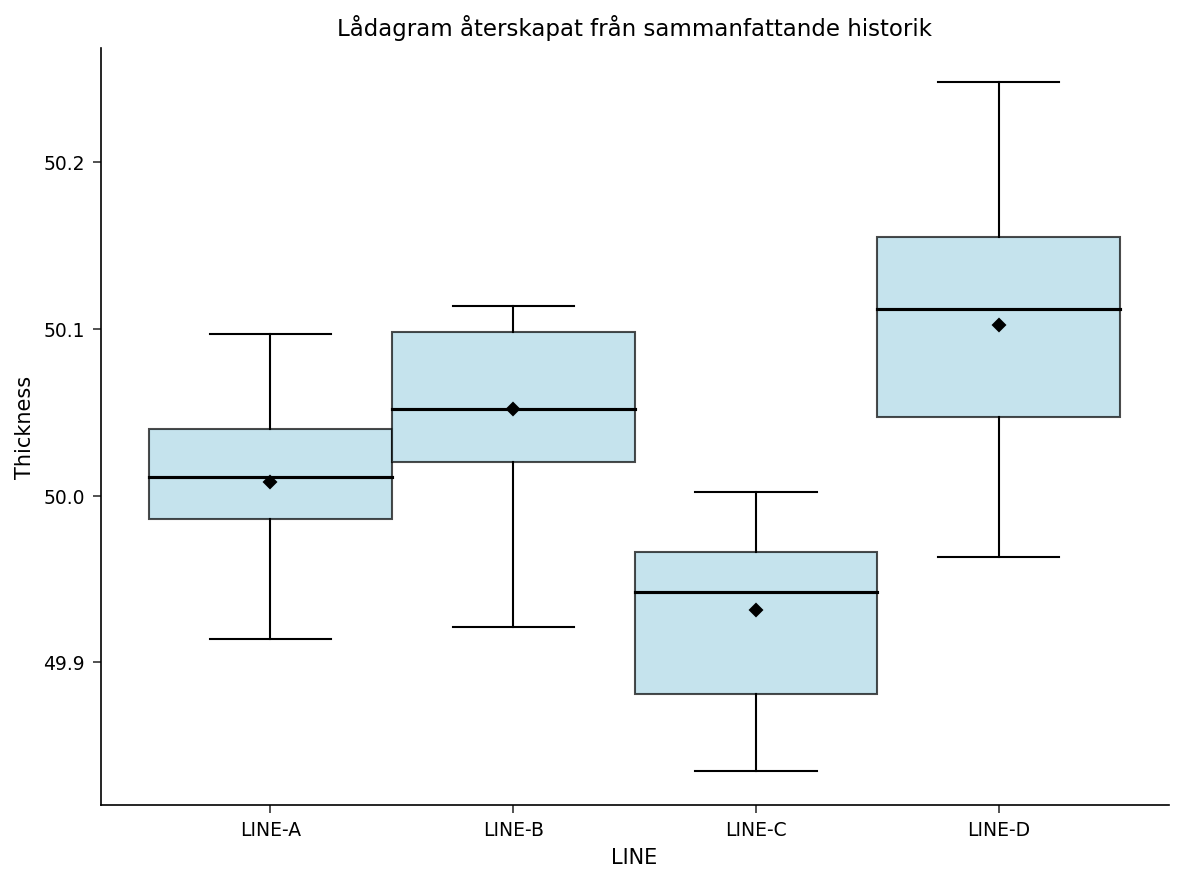

In [6]:
TITEL 'Exportera delgruppshistorik';
PROCEDUR boxplot data=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
KÖR;

TITEL 'Sammanfattande historikdataset (en rad per linje)';
PROCEDUR SKRIV data=LineHistory noobs;
KÖR;

TITEL 'Lådagram återskapat från sammanfattande historik';
PROCEDUR boxplot history=LineHistory;
   PLOT Thickness*Line;
KÖR;

## Tolkning av resultaten

Genom att läsa lådagrammen tillsammans med `PROC MEANS`-profilen, `OUTBOX=`-tabellen och specifikationsgränsbedömningen:

- **Centrering.** `LINE-A` är bäst centrerad på målvärdet 50,00 mm (medelvärde 50,008 mm, median 50,011 mm). `LINE-B` ligger något högt (medelvärde 50,052 mm). `LINE-C` ligger lågt (medelvärde 49,932 mm, median 49,942 mm), linjen som driver mot LSL. `LINE-D` ligger högt (medelvärde 50,102 mm, median 50,112 mm), linjen närmast USL.
- **Spridning.** `LINE-D` visar den bredaste lådan och de längsta morrhåren — dess standardavvikelse på 0,080 mm är ungefär 60–80 % större än de andra tre linjerna (0,045–0,051 mm), vilket flaggar den som den minst stabila linjen och den bästa kandidaten för en studie av variationsminskning. `LINE-A` är den tightaste (standardavvikelse 0,045 mm).
- **Svansar.** I schematisk stil producerar ingen linje ett avvikande värde utanför staketet: varje morrhår når sin linjes verkliga min/max, så processen kastar inte ut isolerade extrema detaljer. Spridningsskillnaderna drivs av huvuddelen av varje fördelning, inte av strökpunkter.
- **Specifikationsöverensstämmelse.** `OUTBOX=`-morrhårsändpunkterna, bedömda mot 49,80 / 50,20 mm, placerar `LINE-A`, `LINE-B` och `LINE-C` helt **inom specifikationen**. `LINE-D` är undantaget: dess höga morrhår når **50,248 mm**, förbi **USL på 50,20 mm** — höga detaljer på `LINE-D` överskrider den övre specifikationen.
- **Operationalisering.** `OUTBOX=`-datasetet ger revisorer de exakta kvartilerna, morrhårsändpunkterna, medelvärdet och standardavvikelsen bakom bilden, och `OUTHISTORY=` tillhandahåller en kompakt, omritningsbar sammanfattning med en rad per linje (Steg 6) så att diagrammet kan regenereras enligt ett schema utan att behålla rådata — lådagrammet rekonstruerat från sammanfattningen är identiskt med det som ritats från rådata.

**Åtgärdspunkter:** prioritera `LINE-D` — både omcentrera den nedåt mot målvärdet och starta en studie av variationsminskning för att dra dess höga morrhår tillbaka innanför USL; knuffa `LINE-C` uppåt mot målvärdet innan dess låga svans når LSL; `LINE-A` och `LINE-B` körs på ett acceptabelt sätt.